In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import timm  # for InceptionResNetV2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

/home/cse/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

Using device: cuda


# Problem - 1 : Build the simple CNN model and find out the accuracy

In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  # (32x32x3) -> (32x32x32)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # -> (16x16x32)

            nn.Conv2d(32, 64, 3, padding=1), # -> (16x16x64)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # -> (8x8x64)

            nn.Conv2d(64, 64, 3, padding=1), # -> (8x8x64)
            nn.ReLU()
        )
        self.fc = nn.Sequential(
        nn.Flatten(),
        nn.LazyLinear(64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )


    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = SmallCNN().to(device)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training loop
num_epochs = 20
train_acc_list, val_acc_list = [], []

for epoch in range(num_epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_acc_list.append(train_acc)
    
    # Evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = correct / total
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/20], Train Acc: 0.7077, Val Acc: 0.6893
Epoch [2/20], Train Acc: 0.7480, Val Acc: 0.7119
Epoch [3/20], Train Acc: 0.7803, Val Acc: 0.7101
Epoch [4/20], Train Acc: 0.8081, Val Acc: 0.7321
Epoch [5/20], Train Acc: 0.8342, Val Acc: 0.7333
Epoch [6/20], Train Acc: 0.8572, Val Acc: 0.7235
Epoch [7/20], Train Acc: 0.8759, Val Acc: 0.7347
Epoch [8/20], Train Acc: 0.8980, Val Acc: 0.7180
Epoch [9/20], Train Acc: 0.9144, Val Acc: 0.7270
Epoch [10/20], Train Acc: 0.9255, Val Acc: 0.7211
Epoch [11/20], Train Acc: 0.9373, Val Acc: 0.7219
Epoch [12/20], Train Acc: 0.9440, Val Acc: 0.7255
Epoch [13/20], Train Acc: 0.9529, Val Acc: 0.7190
Epoch [14/20], Train Acc: 0.9579, Val Acc: 0.7212
Epoch [15/20], Train Acc: 0.9607, Val Acc: 0.7177
Epoch [16/20], Train Acc: 0.9662, Val Acc: 0.7202
Epoch [17/20], Train Acc: 0.9613, Val Acc: 0.7187
Epoch [18/20], Train Acc: 0.9673, Val Acc: 0.7205
Epoch [19/20], Train Acc: 0.9700, Val Acc: 0.7230
Epoch [20/20], Train Acc: 0.9737, Val Acc: 0.7216


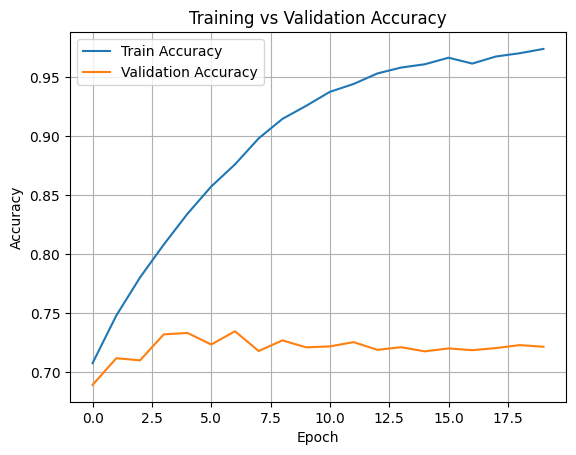

In [6]:
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(val_acc_list, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Problem - 2 : Fine tunned the ResNet50 and InceptionResNetV2 and find out the accuracy

In [4]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Needed for InceptionResNetV2 input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [5]:
def get_resnet50_model():
    model = models.resnet50(pretrained=True)
    
    for param in model.parameters():
        param.requires_grad = False
    
    for param in list(model.layer4.parameters())[-2:]:
        param.requires_grad = True
    
    # Replace final FC layer
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 10)  # 10 classes
    )
    
    return model.to(device)

# 3. Fine-tune InceptionResNetV2 using `timm`
def get_inception_resnet_model():
    model = timm.create_model('inception_resnet_v2', pretrained=True, num_classes=10)

    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # ✅ Unfreeze only the classifier layers (head)
    for param in model.get_classifier().parameters():
        param.requires_grad = True

    return model.to(device)


In [6]:
def train_model(model, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    
    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total
        train_acc_list.append(train_acc)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = correct / total
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return train_acc_list, val_acc_list

In [11]:
print("\nTraining ResNet50:")
resnet_model = get_resnet50_model()
resnet_train_acc, resnet_val_acc = train_model(resnet_model)
torch.save(resnet_model.state_dict(), 'resnet50_finetuned.pth')


Training ResNet50:


/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 - Train Acc: 0.5836, Val Acc: 0.7228
Epoch 2/20 - Train Acc: 0.7065, Val Acc: 0.7436
Epoch 3/20 - Train Acc: 0.7288, Val Acc: 0.7582
Epoch 4/20 - Train Acc: 0.7442, Val Acc: 0.7681
Epoch 5/20 - Train Acc: 0.7513, Val Acc: 0.7663
Epoch 6/20 - Train Acc: 0.7589, Val Acc: 0.7707
Epoch 7/20 - Train Acc: 0.7643, Val Acc: 0.7808
Epoch 8/20 - Train Acc: 0.7655, Val Acc: 0.7767
Epoch 9/20 - Train Acc: 0.7706, Val Acc: 0.7820
Epoch 10/20 - Train Acc: 0.7723, Val Acc: 0.7835
Epoch 11/20 - Train Acc: 0.7769, Val Acc: 0.7820
Epoch 12/20 - Train Acc: 0.7792, Val Acc: 0.7891
Epoch 13/20 - Train Acc: 0.7804, Val Acc: 0.7909
Epoch 14/20 - Train Acc: 0.7846, Val Acc: 0.7897
Epoch 15/20 - Train Acc: 0.7843, Val Acc: 0.7928
Epoch 16/20 - Train Acc: 0.7878, Val Acc: 0.7914
Epoch 17/20 - Train Acc: 0.7920, Val Acc: 0.7950
Epoch 18/20 - Train Acc: 0.7904, Val Acc: 0.7927
Epoch 19/20 - Train Acc: 0.7959, Val Acc: 0.7938
Epoch 20/20 - Train Acc: 0.7954, Val Acc: 0.7962


In [16]:
print("\nTraining InceptionResNetV2:")
inception_model = get_inception_resnet_model()
inception_train_acc, inception_val_acc = train_model(inception_model)
torch.save(inception_model.state_dict(), 'inceptionresnetv2_finetuned.pth')


Training InceptionResNetV2:
Epoch 1/20 - Train Acc: 0.6367, Val Acc: 0.7114
Epoch 2/20 - Train Acc: 0.7190, Val Acc: 0.7260
Epoch 3/20 - Train Acc: 0.7315, Val Acc: 0.7367
Epoch 4/20 - Train Acc: 0.7397, Val Acc: 0.7457
Epoch 5/20 - Train Acc: 0.7466, Val Acc: 0.7505
Epoch 6/20 - Train Acc: 0.7518, Val Acc: 0.7520
Epoch 7/20 - Train Acc: 0.7554, Val Acc: 0.7558
Epoch 8/20 - Train Acc: 0.7616, Val Acc: 0.7622
Epoch 9/20 - Train Acc: 0.7648, Val Acc: 0.7589
Epoch 10/20 - Train Acc: 0.7681, Val Acc: 0.7630
Epoch 11/20 - Train Acc: 0.7701, Val Acc: 0.7668
Epoch 12/20 - Train Acc: 0.7726, Val Acc: 0.7668
Epoch 13/20 - Train Acc: 0.7755, Val Acc: 0.7695
Epoch 14/20 - Train Acc: 0.7754, Val Acc: 0.7743
Epoch 15/20 - Train Acc: 0.7755, Val Acc: 0.7734
Epoch 16/20 - Train Acc: 0.7789, Val Acc: 0.7725
Epoch 17/20 - Train Acc: 0.7789, Val Acc: 0.7742
Epoch 18/20 - Train Acc: 0.7809, Val Acc: 0.7740
Epoch 19/20 - Train Acc: 0.7836, Val Acc: 0.7760
Epoch 20/20 - Train Acc: 0.7842, Val Acc: 0.7770


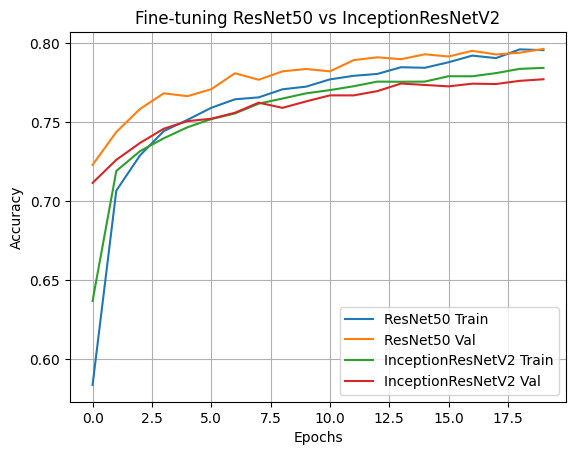

In [17]:
plt.plot(resnet_train_acc, label='ResNet50 Train')
plt.plot(resnet_val_acc, label='ResNet50 Val')
plt.plot(inception_train_acc, label='InceptionResNetV2 Train')
plt.plot(inception_val_acc, label='InceptionResNetV2 Val')
plt.title("Fine-tuning ResNet50 vs InceptionResNetV2")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
resnet_loaded = get_resnet50_model()
resnet_loaded.load_state_dict(torch.load('resnet50_finetuned.pth'))
resnet_loaded.eval()
print("ResNet50 model loaded.")

inception_loaded = get_inception_resnet_model()
inception_loaded.load_state_dict(torch.load('inceptionresnetv2_finetuned.pth'))
inception_loaded.eval()
print("InceptionResNetV2 model loaded.")

/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cse/.local/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet50 model loaded.
InceptionResNetV2 model loaded.


# Problem - 3 : Distillated the knowledge from the ResNet50 and InceptionResNetV2 to the SmallCNN model

In [8]:
import torch.nn.functional as F

def distillation_loss(y_student, y_teacher, y_true, alpha=0.5, T=3):

    loss_soft = F.kl_div(
        F.log_softmax(y_student / T, dim=1),
        F.softmax(y_teacher / T, dim=1),
        reduction='batchmean'
    ) * (T * T)

    loss_hard = F.cross_entropy(y_student, y_true)

    return alpha * loss_soft + (1 - alpha) * loss_hard

In [14]:
def train_distilled_model(student_model, teacher_model, model_name, epochs=20):
    optimizer = torch.optim.AdamW(student_model.parameters(), lr=1e-3)

    best_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        student_model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                teacher_outputs = teacher_model(images)

            student_outputs = student_model(images)
            loss = distillation_loss(student_outputs, teacher_outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(student_outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = correct / total
        print(f"{model_name} Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_model_state = student_model.state_dict()

    # Save best model
    torch.save(best_model_state, f"{model_name}_student.pth")
    print(f"\nBest student model from {model_name} saved with accuracy: {best_acc:.4f}")
    return best_acc

def evaluate_model(model, dataloader, name="Student"):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    print(f"\n{name} model test accuracy: {acc:.4f}")
    return acc


In [25]:
teacher_model_resnet = get_resnet50_model()
teacher_model_resnet.load_state_dict(torch.load("resnet50_finetuned.pth"))
teacher_model_resnet.eval().to(device)

student_model_resnet = SmallCNN().to(device)
train_accuracy_resnet = train_distilled_model(student_model_resnet, teacher_model_resnet, model_name="resnet50")

student_model_resnet.load_state_dict(torch.load("resnet50_student.pth"))
test_accuracy_resnet = evaluate_model(student_model_resnet, testloader, name="ResNet50 Student")

print(f"Distilated accuracy after using ResNet50:\nTrain: {train_accuracy_resnet:.4f}, Test: {test_accuracy_resnet:.4f}")

resnet50 Epoch [1/20], Loss: 1847.7651, Accuracy: 0.4355
resnet50 Epoch [2/20], Loss: 1495.7523, Accuracy: 0.5211
resnet50 Epoch [3/20], Loss: 1323.6387, Accuracy: 0.5713
resnet50 Epoch [4/20], Loss: 1133.5340, Accuracy: 0.6311
resnet50 Epoch [5/20], Loss: 957.8238, Accuracy: 0.6935
resnet50 Epoch [6/20], Loss: 824.2071, Accuracy: 0.7485
resnet50 Epoch [7/20], Loss: 711.1665, Accuracy: 0.7956
resnet50 Epoch [8/20], Loss: 611.4242, Accuracy: 0.8397
resnet50 Epoch [9/20], Loss: 528.3495, Accuracy: 0.8766
resnet50 Epoch [10/20], Loss: 459.6996, Accuracy: 0.9086
resnet50 Epoch [11/20], Loss: 406.4507, Accuracy: 0.9291
resnet50 Epoch [12/20], Loss: 366.8371, Accuracy: 0.9429
resnet50 Epoch [13/20], Loss: 339.1274, Accuracy: 0.9496
resnet50 Epoch [14/20], Loss: 317.4407, Accuracy: 0.9563
resnet50 Epoch [15/20], Loss: 305.1914, Accuracy: 0.9564
resnet50 Epoch [16/20], Loss: 289.7142, Accuracy: 0.9615
resnet50 Epoch [17/20], Loss: 275.6063, Accuracy: 0.9629
resnet50 Epoch [18/20], Loss: 266.99

In [ ]:
teacher_model_inception = get_inception_resnet_model()
teacher_model_inception.load_state_dict(torch.load("inceptionresnetv2_finetuned.pth"))
teacher_model_inception.eval().to(device)

student_model_inception = SmallCNN().to(device)
train_accuracy_inception = train_distilled_model(student_model_inception, teacher_model_inception, model_name="inceptionresnetv2")

student_model_inception.load_state_dict(torch.load("inceptionresnetv2_student.pth"))
test_accuracy_inception = evaluate_model(student_model_inception, testloader, name="InceptionResNetV2 Student")

print(f"Distilated  accuracy after using InceptionResNetV2:\nTrain: {train_accuracy_inception:.4f}, Test: {test_accuracy_inception:.4f}")

inceptionresnetv2 Epoch [1/20], Loss: 1589.4950, Accuracy: 0.4304
inceptionresnetv2 Epoch [2/20], Loss: 1314.0809, Accuracy: 0.5232
inceptionresnetv2 Epoch [3/20], Loss: 1136.1400, Accuracy: 0.5927
inceptionresnetv2 Epoch [4/20], Loss: 1006.3292, Accuracy: 0.6473
inceptionresnetv2 Epoch [5/20], Loss: 872.7025, Accuracy: 0.7054
inceptionresnetv2 Epoch [6/20], Loss: 749.1245, Accuracy: 0.7666
inceptionresnetv2 Epoch [7/20], Loss: 622.9186, Accuracy: 0.8292
inceptionresnetv2 Epoch [8/20], Loss: 511.2320, Accuracy: 0.8859
inceptionresnetv2 Epoch [9/20], Loss: 424.3531, Accuracy: 0.9255
inceptionresnetv2 Epoch [10/20], Loss: 365.0508, Accuracy: 0.9496
inceptionresnetv2 Epoch [11/20], Loss: 327.4171, Accuracy: 0.9599
inceptionresnetv2 Epoch [12/20], Loss: 302.4566, Accuracy: 0.9671
inceptionresnetv2 Epoch [13/20], Loss: 286.3556, Accuracy: 0.9689
inceptionresnetv2 Epoch [14/20], Loss: 272.6009, Accuracy: 0.9704
inceptionresnetv2 Epoch [15/20], Loss: 260.0593, Accuracy: 0.9729
inceptionresnet

: 

# Problem-4 : Use the two class teacher model

In [10]:
def ensemble_distillation_loss(student_logits, teacher1_logits, teacher2_logits, labels, alpha=0.7, T=4):
    avg_teacher_logits = (teacher1_logits + teacher2_logits) / 2.0

    soft_loss = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(avg_teacher_logits / T, dim=1),
        reduction='batchmean'
    ) * (T * T)

    hard_loss = F.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1 - alpha) * hard_loss

In [11]:
def train_and_evaluate_dual_teacher(student_model, resnet_teacher, inception_teacher, optimizer, num_epochs=20):
    train_acc_list = []

    for epoch in range(num_epochs):
        student_model.train()
        total_loss, total_correct, total = 0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                logits_resnet = resnet_teacher(images)
                logits_incep = inception_teacher(images)

            # Student prediction
            logits_student = student_model(images)

            # Loss
            loss = ensemble_distillation_loss(logits_student, logits_resnet, logits_incep, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accuracy
            _, preds = torch.max(logits_student, 1)
            total_correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()

        acc = total_correct / total
        train_acc_list.append(acc)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {total_loss:.4f} - Train Acc: {acc:.4f}")

    # Final train accuracy
    final_train_acc = train_acc_list[-1]

    # --- Evaluation ---
    student_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = student_model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    final_test_acc = correct / total
    print(f"\nFinal Train Accuracy: {final_train_acc:.4f}")
    print(f"Final Test Accuracy : {final_test_acc:.4f}")

    # Save model
    torch.save(student_model.state_dict(), "small_cnn_distilled_from_two_teachers.pth")
    print("Student model saved as 'small_cnn_distilled_from_two_teachers.pth'")

    return train_acc_list, final_train_acc, final_test_acc


In [12]:
resnet_teacher = get_resnet50_model()
resnet_teacher.load_state_dict(torch.load("resnet50_finetuned.pth"))
resnet_teacher.eval().to(device)

inception_teacher = get_inception_resnet_model()
inception_teacher.load_state_dict(torch.load("inceptionresnetv2_finetuned.pth"))
inception_teacher.eval().to(device)

student_model = SmallCNN().to(device)

optimizer = torch.optim.AdamW(student_model.parameters(), lr=1e-3)

In [13]:
train_acc_list, final_train_acc, final_test_acc = train_and_evaluate_dual_teacher(
    student_model, resnet_teacher, inception_teacher, optimizer, num_epochs=20)
print(f"After using both ResNet50 and InceptionResNetV2 as a teacher model \nFinal Train Accuracy: {final_train_acc:.4f}, Final Test Accuracy: {final_test_acc:.4f}")

Epoch [1/20] - Loss: 1762.3972 - Train Acc: 0.4362
Epoch [2/20] - Loss: 1403.3771 - Train Acc: 0.5179
Epoch [3/20] - Loss: 1146.4691 - Train Acc: 0.5867
Epoch [4/20] - Loss: 967.8168 - Train Acc: 0.6474
Epoch [5/20] - Loss: 855.5411 - Train Acc: 0.6870
Epoch [6/20] - Loss: 750.2183 - Train Acc: 0.7288
Epoch [7/20] - Loss: 638.4757 - Train Acc: 0.7741
Epoch [8/20] - Loss: 545.8521 - Train Acc: 0.8143
Epoch [9/20] - Loss: 468.2513 - Train Acc: 0.8471
Epoch [10/20] - Loss: 405.8831 - Train Acc: 0.8743
Epoch [11/20] - Loss: 361.8668 - Train Acc: 0.8940
Epoch [12/20] - Loss: 325.1561 - Train Acc: 0.9076
Epoch [13/20] - Loss: 299.7108 - Train Acc: 0.9193
Epoch [14/20] - Loss: 279.8734 - Train Acc: 0.9249
Epoch [15/20] - Loss: 265.3223 - Train Acc: 0.9312
Epoch [16/20] - Loss: 252.6232 - Train Acc: 0.9364
Epoch [17/20] - Loss: 242.0501 - Train Acc: 0.9375
Epoch [18/20] - Loss: 232.9507 - Train Acc: 0.9419
Epoch [19/20] - Loss: 224.8570 - Train Acc: 0.9430
Epoch [20/20] - Loss: 216.2593 - Trai